# Thực hiện Endcoding bộ dữ liệu

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# --- CÁC CÔNG CỤ XỬ LÝ DỮ LIỆU ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Tải dữ liệu 

In [2]:
try:
    # Thay 'bonbanh_data.csv' bằng tên file 7000 mẫu của bạn
    data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Tài liệu\\KHDL\\Project_02\\bonbanh_data_cleaned_no_outliers.csv') 
    
    # *** Xử lý sơ bộ dữ liệu bị thiếu (NaN) ***
    # Dựa trên file .csv, cột 'Số km đã đi' có thể là 'N/A'
    # Chúng ta cần chuyển 'N/A' thành NaN (dạng số) để xử lý
    data['Số km đã đi'] = pd.to_numeric(data['Số km đã đi'], errors='coerce')
    
    # Logic: Nếu 'Tình trạng' là 'Xe mới', 'Số km' thiếu thì điền là 0
    data.loc[data['Tình trạng'] == 'Xe mới', 'Số km đã đi'] = \
        data.loc[data['Tình trạng'] == 'Xe mới', 'Số km đã đi'].fillna(0)
    
    # Loại bỏ các cột không cần thiết cho dự đoán
    data = data.drop(columns=['Ngày đăng bài', 'Tên xe'])
    
    # Loại bỏ các dòng có nhãn (Kiểu dáng) bị thiếu
    data = data.dropna(subset=['Kiểu dáng'])

except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'bonbanh_data.csv'.")
    exit()

print("Tải và xử lý sơ bộ dữ liệu thành công.\n")

Tải và xử lý sơ bộ dữ liệu thành công.



--- Đang vẽ Biểu đồ Phân bố Kiểu dáng xe ---
ĐÃ LƯU BIỂU ĐỒ PHÂN BỐ VÀO FILE 'kieudang_distribution.png'



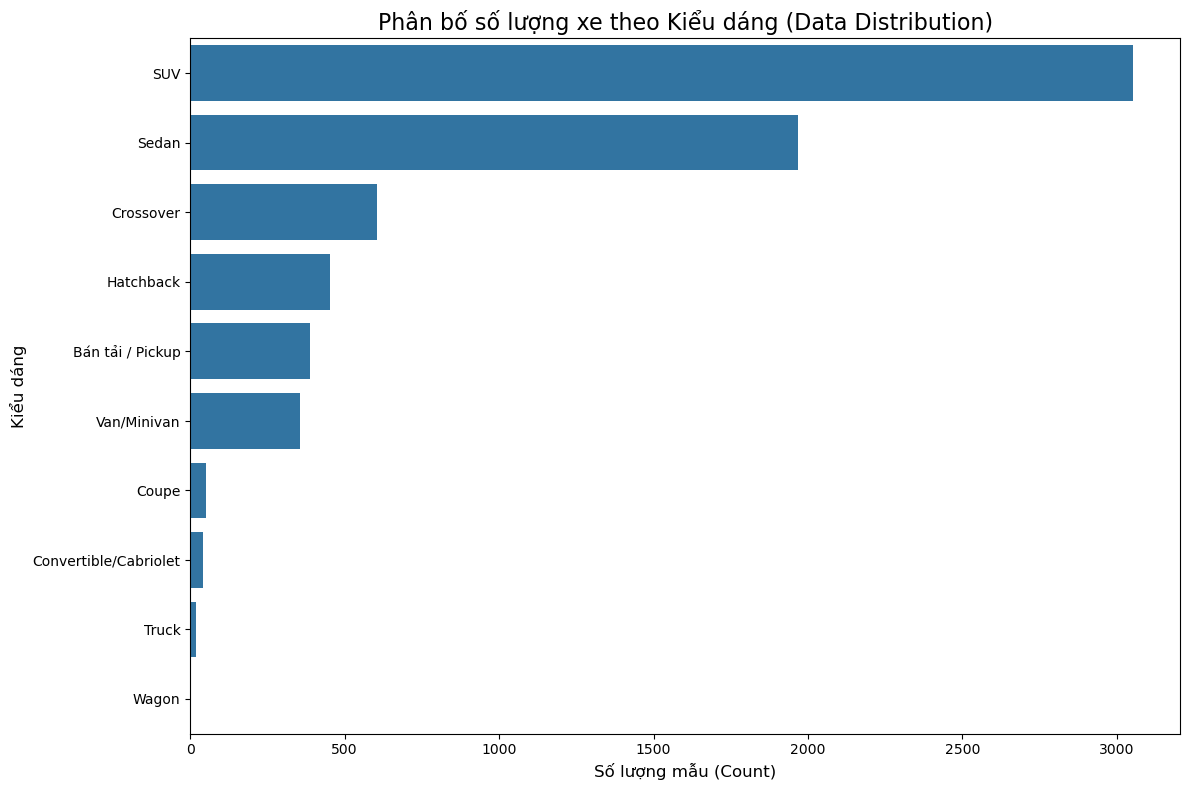

In [ ]:
print("--- Đang vẽ Biểu đồ Phân bố Kiểu dáng xe ---")
plt.figure(figsize=(12, 8)) 
sns.countplot(
    y=data['Kiểu dáng'],
    order=data['Kiểu dáng'].value_counts().index
)

plt.title('Phân bố số lượng xe theo Kiểu dáng (Data Distribution)', fontsize=16)
plt.xlabel('Số lượng mẫu (Count)', fontsize=12)
plt.ylabel('Kiểu dáng', fontsize=12)
plt.tight_layout() 

# Lưu biểu đồ ra file
plt.savefig('kieudang_distribution.png', dpi=300)
print("ĐÃ LƯU BIỂU ĐỒ PHÂN BỐ VÀO FILE 'kieudang_distribution.png'\n")

# Tách biến độc lập (X) và (Y)

In [3]:
target_column = 'Kiểu dáng'
X = data.drop(columns=[target_column])
y = data[target_column]

# Tách Train/Test (Chia dữ liệu)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Giúp chia đều tỷ lệ các kiểu dáng vào 2 tập
)

# Xây dựng PipeLine xử lý và chuẩn hóa

In [5]:
numeric_features = ['Năm SX', 'Giá', 'Số km đã đi']
categorical_features = ['Xuất xứ', 'Địa điểm', 'Hộp số', 'Tình trạng', 'Nhiên liệu']
# 4.2. Tạo pipeline xử lý cho cột SỐ
# 1. SimpleImputer: Tự động điền giá trị thiếu (NaN) bằng giá trị trung vị
# 2. StandardScaler: Thực hiện Feature Scaling (Chuẩn hóa)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# 4.3. Tạo pipeline xử lý cho cột CHỮ
# 1. SimpleImputer: Tự động điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất
# 2. OneHotEncoder: Thực hiện Mã hóa (Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# 4.4. Kết hợp hai pipeline trên bằng ColumnTransformer
# Đây là bộ tiền xử lý hoàn chỉnh
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
])

# Khởi tạo mô hình SVM với chiến thuật OvO

In [9]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf', 
        C=1.0, 
        gamma='scale',
        decision_function_shape='ovo', # Chỉ định rõ chiến lược OvO
        class_weight='balanced'  # Tự động điều chỉnh trọng số cho các lớp
    ))
])

# Huấn luyện mô hình

In [ ]:
print("Bắt đầu huấn luyện mô hình...")
# Giờ đây chúng ta huấn luyện trên X_train THÔ
# Pipeline sẽ tự động xử lý và chuẩn hóa dữ liệu
model_pipeline.fit(X_train, y_train)
print("Huấn luyện hoàn tất!\n")

# --- Bước 7: Dự đoán (Predict) ---
print("Đang dự đoán trên tập kiểm thử...")
y_pred = model_pipeline.predict(X_test)

# --- Bước 8: Đánh giá (Evaluate) ---
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---\n")

accuracy = accuracy_score(y_test, y_pred)
print(f"📈 Độ chính xác (Accuracy): {accuracy * 100:.2f}%\n")

print("📊 Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred))

print("🔀 Ma trận nhầm lẫn:")
class_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=class_labels)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
print(cm_df)

Bắt đầu huấn luyện mô hình...
Huấn luyện hoàn tất!

Đang dự đoán trên tập kiểm thử...
--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---

📈 Độ chính xác (Accuracy): 38.14%

📊 Báo cáo phân loại chi tiết:
                       precision    recall  f1-score   support

   Bán tải / Pickup       0.54      0.90      0.67        78
Convertible/Cabriolet       0.05      0.62      0.10         8
                Coupe       0.06      0.60      0.12        10
            Crossover       0.25      0.60      0.35       121
            Hatchback       0.33      0.57      0.42        90
                  SUV       0.74      0.22      0.35       610
                Sedan       0.50      0.41      0.45       394
                Truck       0.16      0.75      0.26         4
          Van/Minivan       0.30      0.35      0.32        71
                Wagon       0.00      0.00      0.00         1

             accuracy                           0.38      1387
            macro avg       0.29      0.50      0.30     

In [17]:

import joblib
# --- Bước 9: Lưu Mô hình (Save Model) ---
print("\n--- Đang lưu mô hình đã huấn luyện ---")
try:
    joblib.dump(model_pipeline, 'svm_car_model.joblib')
    print("Đã lưu mô hình thành công vào file 'svm_car_model.joblib'!")
    print("Giờ đây bạn có thể dùng file 'app_du_doan.py' để thực hiện Case Studies.")
except Exception as e:
    print(f"LỖI: Không thể lưu mô hình. Lỗi: {e}")


--- Đang lưu mô hình đã huấn luyện ---
Đã lưu mô hình thành công vào file 'svm_car_model.joblib'!
Giờ đây bạn có thể dùng file 'app_du_doan.py' để thực hiện Case Studies.



--- Đang vẽ Heatmap Ma trận nhầm lẫn ---
ĐÃ LƯU HEATMAP VÀO FILE 'confusion_matrix_heatmap.png'


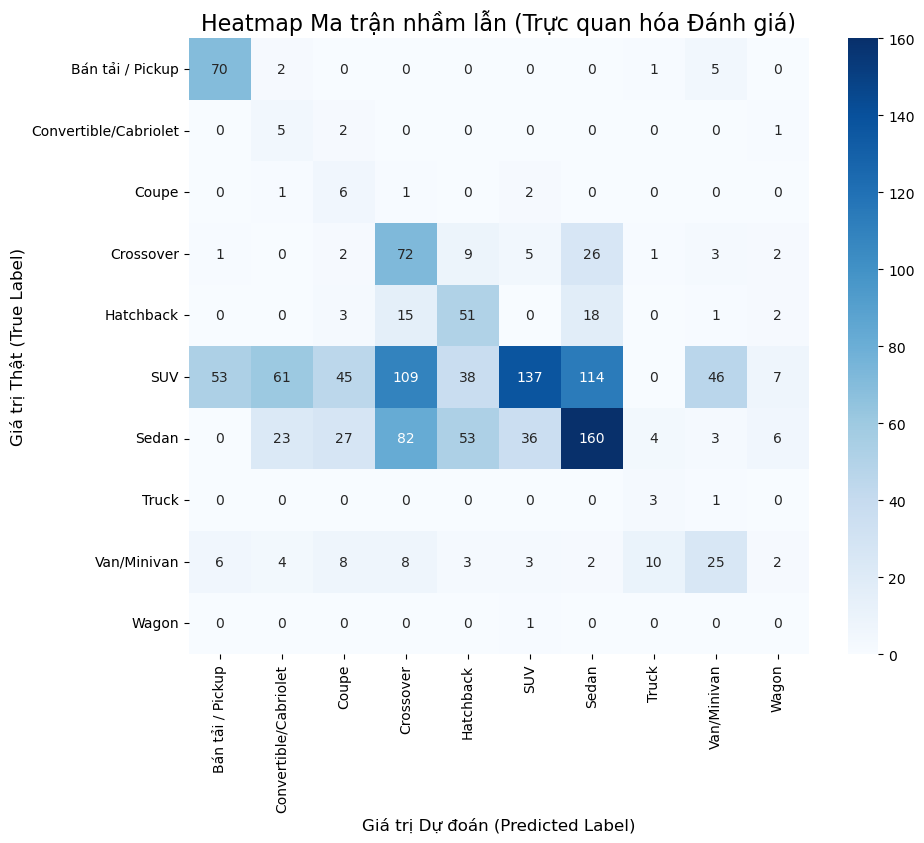

In [21]:
# ... (Bạn vừa in cm_df ở Bước 8) ...

# ===================================================================
# ▼▼▼ BẠN THÊM ĐOẠN CODE VẼ HEATMAP VÀO ĐÂY ▼▼▼
# ===================================================================

# Import thư viện (nếu chưa có ở đầu file)
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Đang vẽ Heatmap Ma trận nhầm lẫn ---")

# Thiết lập kích thước khung ảnh
plt.figure(figsize=(10, 8))

# Sử dụng Seaborn để vẽ heatmap
# 'cm' là biến ma trận nhầm lẫn bạn đã tính ở Bước 8
# 'class_labels' là tên các kiểu dáng (Sedan, SUV...)
sns.heatmap(
    cm, 
    annot=True,     # Hiển thị số lượng lên trên ô
    fmt='g',        # Định dạng số (không dùng ký hiệu khoa học)
    cmap='Blues',   # Dùng thang màu Xanh
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Heatmap Ma trận nhầm lẫn (Trực quan hóa Đánh giá)', fontsize=16)
plt.xlabel('Giá trị Dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Giá trị Thật (True Label)', fontsize=12)

# Lưu biểu đồ ra file
plt.savefig('confusion_matrix_heatmap.png', dpi=300, bbox_inches='tight')
print("ĐÃ LƯU HEATMAP VÀO FILE 'confusion_matrix_heatmap.png'")

# ===================================================================
# ▲▲▲ KẾT THÚC PHẦN CODE VẼ HEATMAP ▲▲▲
# ===================================================================

In [20]:
# -*- coding: utf-8 -*-
import joblib
import pandas as pd

# --- Bước 1: Tải mô hình đã được huấn luyện ---
# Giả sử file code này nằm CÙNG THƯ MỤC với file .joblib
try:
    # Tải file model tốt nhất bạn đã lưu từ bước GridSearchCV
    model = joblib.load('svm_car_model.joblib') 
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'svm_car_model.joblib'.")
    print("Hãy chắc chắn rằng bạn đã chạy file huấn luyện và lưu mô hình.")
    exit()
    
print("Tải mô hình thành công!\n")

# --- Bước 2: Định nghĩa các Tình huống Nghiên cứu (Case Studies) ---
# Chúng ta sẽ tạo 3 chiếc xe "tưởng tượng" với thông tin thô
# Lưu ý: Các tên cột ('Năm SX', 'Giá', 'Xuất xứ'...)
# PHẢI GIỐNG HỆT tên cột trong file .csv gốc của bạn.

# Case 1: Một chiếc SUV đời mới, giá cao, điển hình
case_1 = {
    'Năm SX': 2022,
    'Giá': 1100000000.0,
    'Xuất xứ': 'Nhập khẩu',
    'Địa điểm': 'TP HCM',
    'Số km đã đi': 30000.0,
    'Hộp số': 'Tự động',
    'Tình trạng': 'Đã sử dụng',
    'Nhiên liệu': 'Xăng'
}

# Case 2: Một chiếc xe nhỏ, giá rẻ (dễ nhầm lẫn Hatchback/Sedan)
case_2 = {
    'Năm SX': 2018,
    'Giá': 350000000.0,
    'Xuất xứ': 'Nội địa',
    'Địa điểm': 'Hà Nội',
    'Số km đã đi': 75000.0,
    'Hộp số': 'Số sàn',
    'Tình trạng': 'Đã sử dụng',
    'Nhiên liệu': 'Xăng'
}

# Case 3: Một chiếc xe Bán tải điển hình (máy dầu)
case_3 = {
    'Năm SX': 2021,
    'Giá': 800000000.0,
    'Xuất xứ': 'Nhập khẩu',
    'Địa điểm': 'TP HCM',
    'Số km đã đi': 45000.0,
    'Hộp số': 'Tự động',
    'Tình trạng': 'Đã sử dụng',
    'Nhiên liệu': 'Dầu'
}

# --- Bước 3: Chạy Dự đoán cho từng Case ---

print("="*30)
print("TÌNH HUỐNG 1: SUV ĐIỂN HÌNH")
# Chuyển dictionary thành DataFrame (vì model yêu cầu đầu vào là DataFrame)
X_new_1 = pd.DataFrame([case_1]) 
prediction_1 = model.predict(X_new_1)
print(f"   -> Dự đoán của mô hình: {prediction_1[0]}")

print("="*30)
print("TÌNH HUỐNG 2: XE NHỎ GIÁ RẺ (HATCHBACK/SEDAN)")
X_new_2 = pd.DataFrame([case_2])
prediction_2 = model.predict(X_new_2)
print(f"   -> Dự đoán của mô hình: {prediction_2[0]}")

print("="*30)
print("TÌNH HUỐNG 3: BÁN TẢI MÁY DẦU")
X_new_3 = pd.DataFrame([case_3])
prediction_3 = model.predict(X_new_3)
print(f"   -> Dự đoán của mô hình: {prediction_3[0]}")
print("="*30)

Tải mô hình thành công!

TÌNH HUỐNG 1: SUV ĐIỂN HÌNH
   -> Dự đoán của mô hình: Wagon
TÌNH HUỐNG 2: XE NHỎ GIÁ RẺ (HATCHBACK/SEDAN)
   -> Dự đoán của mô hình: Sedan
TÌNH HUỐNG 3: BÁN TẢI MÁY DẦU
   -> Dự đoán của mô hình: SUV
